# Figure 4

LSV

run at /vento (USP)

Created: 27/01/2025 

Last update: 05/06/2026 

In [64]:
import sys
sys.prefix
import numpy as np # type: ignore
import xarray as xr # type: ignore
import os, glob
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import matplotlib.dates as mdates # type: ignore
import matplotlib.ticker as ticker # type: ignore
import matplotlib.patches as mpatches  # type: ignore
from matplotlib.gridspec import GridSpec # type: ignore
import cmaps # type: ignore
from cmocean import cm # type: ignore
from shapely.geometry.polygon import LinearRing # type: ignore
from scipy import integrate # type: ignore
from scipy import stats # type: ignore
from scipy import signal # type: ignore
from scipy.stats import pearsonr # type: ignore
from scipy.stats import ttest_ind # type: ignore
import seaborn as sns # type: ignore
import cftime # type: ignore
import nc_time_axis # type: ignore
degree_sign= u'\N{DEGREE SIGN}'

#import statsmodels.api as sm # type: ignore
#from mpl_toolkits.axes_grid1 import make_axes_locatable # type: ignore
#import seawater as sw # compute density # type: ignore

In [65]:
def xr_CI(data_array, signif=0.95, dim=None):
    from scipy.stats import t # type: ignore
    """
    Calculate the confidence interval of a DataArray along a specified dimension.

    Parameters:
    data_array (xarray.DataArray): The DataArray to compute the confidence interval on.
    confidence (float): The confidence level, between 0 and 1. Default is 0.95.
    dim (str or None): The dimension along which to calculate the confidence interval. 
                       If None, will compute over the entire dataset.

    Returns:
    xarray.DataArray: A DataArray containing the lower and upper bounds of the confidence interval.
    """
    mean = data_array.mean(dim)
    std = data_array.std(dim)
    n = data_array.count(dim)
    se = std / np.sqrt(n)
    h = se * t.ppf((1 + signif) / 2., n - 1)

    lower_bound = mean - h
    upper_bound = mean + h
    return xr.Dataset({'lb': lower_bound, 'ub': upper_bound})

In [66]:
def stippling_signal_agreement(data,nivel):
    #data = tosMod #np.stack(mv_std_modelos)
    nPos=np.sum(data>=0, axis=-1) # check where the anomaly is positive (sum)
    nNeg=np.sum(data<0, axis=-1) # check where the anomaly is negative
    N = round(data.shape[1]*nivel*.01) # calculates the number of events for reference
    
    if data.dims[0] == 'time':
        scatter_x=data.time[(nPos>=N)+(nNeg>=N)] # create dots to plot (time vs. anomaly)
    elif data.dims[0] == 'year':
        scatter_x=data.year[(nPos>=N)+(nNeg>=N)] # create dots to plot (time vs. anomaly)
    if data.dims[1] == 'ensemble':
        scatter_y=data.mean('ensemble')[(nPos>=N)+(nNeg>=N)]
    elif data.dims[1] == 'record':
        scatter_y=data.mean('record')[(nPos>=N)+(nNeg>=N)]
    
    return scatter_x, scatter_y

In [67]:
def calculate_linear_trend(values): # for variable with time not year
    # Calculate linear fit coefficients
    coeffs = np.polyfit(values.time, values.values, 1)
    slope, intercept = coeffs

    # Predict values using the linear model
    model_predictions = np.polyval([slope, intercept], values.time)

    # Calculate residuals and statistical measures
    residuals = values.values - model_predictions
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((values.values - np.mean(values.values))**2)
    r_squared = 1 - (ss_res / ss_tot)
    degrees_of_freedom = len(values) - 2
    stderr = np.sqrt(ss_res / degrees_of_freedom) / np.sqrt(np.sum((values.time - np.mean(values.time))**2))
    t_stat = slope / stderr
    p_value = stats.t.sf(np.abs(t_stat), degrees_of_freedom) * 2  # two-tailed p-value

    # Output the results
    trend_line = slope * values.time + intercept
    print(f"Linear trend: slope = {slope:.3f} (units/year), intercept = {intercept:.3f}")
    print(f"R-squared: {r_squared:.3f}, p-value: {p_value:.3g}")

    return slope, intercept, r_squared, p_value, trend_line

In [68]:
def standardize(data):
    """ Standardize data to have mean=0 and std=1 """
    return (data - data.mean()) / data.std()

In [69]:
def crosscorr_stdz(datax, datay, lag=0):
    """ Cross correlation with a lag using standardized data for Pearson's r and p-value """
    # Standardizing the data
    datax = (datax - datax.mean()) / datax.std()
    datay = (datay - datay.mean()) / datay.std()
    
    # Shift and drop NaNs to ensure equal length of data
    datax_lagged = datax.shift(time=lag).dropna(dim='time', how='all')
    datay = datay.sel(time=datax_lagged.time)
    r, p = pearsonr(datax_lagged, datay)
    return r, p

In [70]:
def AMOCtransp(vo_zonal, lat_sel, long1, long2):
    """
    Compute the AMOC transport in a given zonal section.

    Parameters:
        vo_zonal (xarray.DataArray): Meridional velocity component with dimensions [time, depthv, lat, lon].
        lat_sel (float): Latitude of the zonal section.
        long1 (float): Starting longitude of the zonal section.
        long2 (float): Ending longitude of the zonal section.

    Returns:
        xarray.DataArray: AMOC transport in Sv (1 Sv = 1e6 m³/s).
    """
    # Select long range
    vo_zonal =  vo_zonal.sel(lon=slice(long1,long2))

    # 1) Zonal Integration
    earth_radius = 6371e3  # Earth's radius in meters
    dlon_rad = np.abs(np.diff(vo_zonal.lon) * np.pi / 180).mean()  # Longitude cell width in radians
    lon_width = dlon_rad * earth_radius * np.cos(lat_sel * np.pi / 180)  # Width of each longitude cell in meters
    meridional_transport = vo_zonal * lon_width # Calculate meridional transport
    meridional_transport_int = meridional_transport.sum(dim='lon') # Integrate zonally

    # 2) Function to find the first depth where the value changes from positive to negative, with depth > 500m
    def find_zero_crossing(depths, values):
        for i in range(len(values) - 1):
            if values[i] > 0 and values[i + 1] < 0 and depths[i] > 500:
                return depths[i]  # Return the depth where the change occurs and depth > 500m
        return np.nan  # Return NaN if no crossing is found

    zero_crossing_depth = xr.apply_ufunc(
        find_zero_crossing,
        meridional_transport_int['depthv'],  # Depth array
        meridional_transport_int,  # Data array
        input_core_dims=[['depthv'], ['depthv']],
        vectorize=True,  # Allow vectorized operation
        output_dtypes=[float],  # Output data type
    )
    
    zero_crossing_depth_broadcast = xr.DataArray( # Broadcast zero_crossing_depth to match the depthv dimension
        zero_crossing_depth.vo,
        dims=['time', 'record']
    ).broadcast_like(meridional_transport_int)

    # 3) Select velocities between sfc and depth inversion
    mask = zero_crossing_depth_broadcast.depthv <= zero_crossing_depth_broadcast # Create a mask where depths are less than or equal to zero_crossing_depth
    meridional_transport_int_surface_to_zero = meridional_transport_int.where(mask) # Apply the mask to meridional_transport_int

    # 4) Vertical Integration
    meridional_transport_int_surface_to_zero_filled = meridional_transport_int_surface_to_zero.fillna(0)     # Replace NaN values with zero before integration
    meridional_transport_int_vert = meridional_transport_int_surface_to_zero_filled.integrate('depthv')
    meridional_transport_int_vert_Sv = meridional_transport_int_vert / 1e6     # Convert to Sv (1 Sv = 1e6 m³/s)

    return meridional_transport_int_vert_Sv


In [72]:
PathDataSets = '/bolha/wk2/laura/dataIPSLpast2k/'
PathFigures = '/home/laura/figures/STC/draft_figures/review1'

In [73]:
slice_clim =slice('1850','1900')
clim_ref = '1850-1900'

In [74]:
plt.rcParams['font.size'] = 14

## * AMOC and WB time series

In [75]:
lat_sel=26 # identify latitude
lat_sel_name='North26'
vo_zonal = xr.open_dataset(PathDataSets+'vo/vo_Omon_AtlZonalAvg'+lat_sel_name+'_CM65-LR-past2k-all_gr_050001-201412_fulldepth.nc')
AMOC26 = AMOCtransp(vo_zonal, lat_sel, -100, 5)
AMOC26smooth = AMOC26.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
AMOC26smooth_conf = xr_CI(AMOC26smooth.vo, signif=0.95, dim='record')

lat_sel=10 # identify latitude
lat_sel_name='North10'
vo_zonal10 = xr.open_dataset(PathDataSets+'vo/vo_Omon_AtlZonalAvg'+lat_sel_name+'_CM65-LR-past2k-all_gr_050001-201412_fulldepth.nc')
AMOC10 = AMOCtransp(vo_zonal10, lat_sel, -65, 10)
AMOC10smooth = AMOC10.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
AMOC10smooth_conf = xr_CI(AMOC10smooth.vo, signif=0.95, dim='record')

lat_sel=-10 # identify latitude
lat_sel_name='South10'
vo_zonal10S = xr.open_dataset(PathDataSets+'vo/vo_Omon_AtlZonalAvg'+lat_sel_name+'_CM65-LR-past2k-all_gr_050001-201412_fulldepth.nc')
AMOC10S = AMOCtransp(vo_zonal10S, lat_sel, -40, 20)
AMOC10Ssmooth = AMOC10S.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
AMOC10Ssmooth_conf = xr_CI(AMOC10Ssmooth.vo, signif=0.95, dim='record')

lat_sel=-24 # identify latitude
lat_sel_name='South24'
vo_zonal24S = xr.open_dataset(PathDataSets+'vo/vo_Omon_AtlZonalAvg'+lat_sel_name+'_CM65-LR-past2k-all_gr_050001-201412_fulldepth.nc')
AMOC24S = AMOCtransp(vo_zonal24S, lat_sel, -55, 20)
AMOC24Ssmooth = AMOC10S.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
AMOC24Ssmooth_conf = xr_CI(AMOC24Ssmooth.vo, signif=0.95, dim='record')


In [76]:
# AMOC anomalies 
AMOC26anom = AMOC26.groupby('time.month') - AMOC26.sel(time=slice_clim).groupby('time.month').mean('time')
AMOC26anom_smooth = AMOC26anom.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
AMOC26anom_smooth2 = AMOC26anom_smooth.assign_coords(time=np.arange(500, 2015))
AMOC26anom_smooth_conf = xr_CI(AMOC26anom_smooth.vo, signif=0.95, dim='record')

AMOC10anom = AMOC10.groupby('time.month') - AMOC10.sel(time=slice_clim).groupby('time.month').mean('time')
AMOC10anom_smooth = AMOC10anom.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
AMOC10anom_smooth_conf = xr_CI(AMOC10anom_smooth.vo, signif=0.95, dim='record')

AMOC10Sanom = AMOC10S.groupby('time.month') - AMOC10S.sel(time=slice_clim).groupby('time.month').mean('time')
AMOC10Sanom_smooth = AMOC10Sanom.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
AMOC10Sanom_smooth_conf = xr_CI(AMOC10Sanom_smooth.vo, signif=0.95, dim='record')

AMOC24Sanom = AMOC24S.groupby('time.month') - AMOC24S.sel(time=slice_clim).groupby('time.month').mean('time')
AMOC24Sanom_smooth = AMOC24Sanom.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
AMOC24Sanom_smooth2 = AMOC24Sanom_smooth.assign_coords(time=np.arange(500, 2015))
AMOC24Sanom_smooth_conf = xr_CI(AMOC24Sanom_smooth.vo, signif=0.95, dim='record')

## * WB thermocline transports

In [77]:
dsVOn = xr.open_dataset(PathDataSets+'vo/vo_Omon_AtlZonalAvgNorth_CM65-LR-past2k-all_gr_050001-201412_exac10N.nc')
dsVOs = xr.open_dataset(PathDataSets+'vo/vo_Omon_AtlZonalAvgSouth_CM65-LR-past2k-all_gr_050001-201412_exac10S.nc')
dsMLD = xr.open_dataset(PathDataSets+'mld/mld_Omon_CM65-LR-past2k-all_gr_050001-201412.nc')
dsTHCD = xr.open_dataset(PathDataSets+'thcd/thcd_Omon_CM65-LR-past2k-all_gr_050001-201412.nc')
dsTHCD = dsTHCD.rename({'rho': 'thcd'})

## lat sections
latNorth1, latNorth2 = 11, 9
latSouth1, latSouth2 = -9,-11

# Select lats for MLDs and THCD 
MLDs = dsMLD.sel(lat=slice(latSouth1,latSouth2)).mean('lat')
THCDs = dsTHCD.sel(lat=slice(latSouth1,latSouth2)).mean('lat')
MLDn = dsMLD.sel(lat=slice(latNorth1,latNorth2)).mean('lat')
THCDn = dsTHCD.sel(lat=slice(latNorth1,latNorth2)).mean('lat')

In [78]:
# 10N
# Select v between MLD and THCD for all times and records
shape = (len(MLDn.time), len(MLDn.lon), len(MLDn.record))
Vn_mldTHCD = xr.full_like(dsVOn, np.nan)

# Iterate and apply conditions
for r in MLDn.record.values:
    for lon in MLDn.lon.values:
        # Extracting the MLD and THCM values for the current record and longitude
        mld_values = MLDn.mld.sel(lon=lon, record=r)
        thcm_values = THCDn.thcd.sel(lon=lon, record=r)

        # Extract the corresponding section of the Vs dataset
        voN = dsVOn.sel(lon=lon, record=r)

        # Applying the condition across the depth dimension
        condition = (voN.depthv > mld_values) & (voN.depthv <= thcm_values)

        # Where the condition is True, replace the corresponding values in the pre-allocated array
        Vn_mldTHCD.loc[dict(lon=lon, record=r)] = voN.where(condition)

# Integrate in the depth (first fill nan with zero)
Vn_mldTHCD_filled = Vn_mldTHCD.fillna(0)

# select pos and neg
ipslVnPOS_mldTHCD = Vn_mldTHCD_filled.where(Vn_mldTHCD_filled > 0, 0)
ipslVnNEG_mldTHCD = Vn_mldTHCD_filled.where(Vn_mldTHCD_filled < 0, 0)

# integrate in the vertical
Vn_intVertPOS = ipslVnPOS_mldTHCD.integrate("depthv")
Vn_intVertNEG = ipslVnNEG_mldTHCD.integrate("depthv")
Vn_intVert = Vn_mldTHCD_filled.integrate("depthv") # total

# Calculate the width of each longitude cell in meters in a latitude (Assume regular grid spacing in longitude)
earth_radius = 6371e3
dlon_rad = np.abs(np.diff(dsVOn.lon) * np.pi / 180).mean()
lon_width = dlon_rad * earth_radius * np.cos(10 * np.pi / 180) # 10 is the latitude of the section

# Multiplies by the longitude width (in meters)
meridional_transportNpos = (Vn_intVertPOS * lon_width)/1e6
meridional_transportNneg = (Vn_intVertNEG * lon_width)/1e6
meridional_transportN = (Vn_intVert * lon_width)/1e6

# Anomaly 
anomTRANSPnPOS = meridional_transportNpos.groupby('time.month') - meridional_transportNpos.sel(time=slice_clim).groupby('time.month').mean('time')
anomTRANSPnNEG = meridional_transportNneg.groupby('time.month') - meridional_transportNneg.sel(time=slice_clim).groupby('time.month').mean('time')
anomTRANSPn = meridional_transportN.groupby('time.month') - meridional_transportN.sel(time=slice_clim).groupby('time.month').mean('time')

In [79]:
# 10S
# Select v between MLD and THCD for all times and records
shape = (len(MLDs.time), len(MLDs.lon), len(MLDs.record))
Vs_mldTHCD = xr.full_like(dsVOs, np.nan)

# Iterate and apply conditions
for r in MLDs.record.values:
    for lon in MLDs.lon.values:
        # Extracting the MLD and THCM values for the current record and longitude
        mld_values = MLDs.mld.sel(lon=lon, record=r)
        thcm_values = THCDs.thcd.sel(lon=lon, record=r)

        # Extract the corresponding section of the Vs dataset
        voS = dsVOs.sel(lon=lon, record=r)

        # Applying the condition across the depth dimension
        condition = (voS.depthv > mld_values) & (voS.depthv <= thcm_values)

        # Where the condition is True, replace the corresponding values in the pre-allocated array
        Vs_mldTHCD.loc[dict(lon=lon, record=r)] = voS.where(condition)

# Integrate in the depth (first fill nan with zero)
Vs_mldTHCD_filled = Vs_mldTHCD.fillna(0)

# select pos and neg
ipslVsPOS_mldTHCD = Vs_mldTHCD_filled.where(Vs_mldTHCD_filled > 0, 0)
ipslVsNEG_mldTHCD = Vs_mldTHCD_filled.where(Vs_mldTHCD_filled < 0, 0)

# integrate in the vertical
Vs_intVertPOS = ipslVsPOS_mldTHCD.integrate("depthv")
Vs_intVertNEG = ipslVsNEG_mldTHCD.integrate("depthv")
Vs_intVert = Vs_mldTHCD_filled.integrate("depthv") # total

# Calculate the width of each longitude cell in meters in a latitude (Assume regular grid spacing in longitude)
earth_radius = 6371e3
dlon_rad = np.abs(np.diff(dsVOs.lon) * np.pi / 180).mean()
lon_width = dlon_rad * earth_radius * np.cos(10 * np.pi / 180) # 10 is the latitude of the section

# Multiplies by the longitude width (in meters)
meridional_transportSpos = (Vs_intVertPOS * lon_width)/1e6
meridional_transportSneg = (Vs_intVertNEG * lon_width)/1e6
meridional_transportS = (Vs_intVert * lon_width)/1e6

# Anomaly 
anomTRANSPsPOS = meridional_transportSpos.groupby('time.month') - meridional_transportSpos.sel(time=slice_clim).groupby('time.month').mean('time')
anomTRANSPsNEG = meridional_transportSneg.groupby('time.month') - meridional_transportSneg.sel(time=slice_clim).groupby('time.month').mean('time')
anomTRANSPs = meridional_transportS.groupby('time.month') - meridional_transportS.sel(time=slice_clim).groupby('time.month').mean('time')


In [80]:
# net transport anomaly for each sector (colored arrows on fig avg) + Sectors as Fu et al. 2022

############################ 10N
# WB (55W to 25W)
lon_slice = slice(-65,-55)
VN_WBCtransp_mldTHCD = -1*meridional_transportN.sel(lon=lon_slice).sum('lon') 
anomVN_WBCtransp_mldTHCD = anomTRANSPn.sel(lon=lon_slice).sum('lon') 
anomVN_WBCtransp_mldTHCD_smooth = -1*anomVN_WBCtransp_mldTHCD.vo.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
anomVN_WBCtransp_mldTHCD_smooth2 = anomVN_WBCtransp_mldTHCD_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
anomVN_WBC_conf = xr_CI(anomVN_WBCtransp_mldTHCD_smooth, signif=0.95, dim='record')
#slopeN_WBC, intercept, r_squared, p_value, trend_lineN_WBC = calculate_linear_trend(anomVN_WBCtransp_mldTHCD_smooth2.mean('record').sel(time=slice(1850,2015)).dropna(dim='time') )

############################ 10S
# WB (65W to 32W)
lon_slice = slice(-65,-32)
VS_WBCtransp_mldTHCD = meridional_transportS.sel(lon=lon_slice).sum('lon') 
anomVS_WBCtransp_mldTHCD = anomTRANSPs.sel(lon=lon_slice).sum('lon') 
anomVS_WBCtransp_mldTHCD_smooth = anomVS_WBCtransp_mldTHCD.vo.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
anomVS_WBCtransp_mldTHCD_smooth2 = anomVS_WBCtransp_mldTHCD_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
anomVS_WBC_conf = xr_CI(anomVS_WBCtransp_mldTHCD_smooth, signif=0.95, dim='record')
#slopeS_WBC, intercept, r_squared, p_value, trend_lineS_WBC = calculate_linear_trend(anomVS_WBCtransp_mldTHCD_smooth2.mean('record').sel(time=slice(1850,2015)).dropna(dim='time') )


## * Lag correlation AMOCs vs AMOCs and WB THCD

In [81]:
AMOC26anom_smooth_avg = AMOC26anom_smooth.vo.mean('record').dropna(dim='time')
AMOC10anom_smooth_avg = AMOC10anom_smooth.vo.mean('record').dropna(dim='time')
AMOC10Sanom_smooth_avg = AMOC10Sanom_smooth.vo.mean('record').dropna(dim='time')
AMOC24Sanom_smooth_avg = AMOC24Sanom_smooth.vo.mean('record').dropna(dim='time')

anomVN_WBCtransp_mldTHCD_smooth_avg = anomVN_WBCtransp_mldTHCD_smooth.mean('record').dropna(dim='time')
anomVS_WBCtransp_mldTHCD_smooth_avg = anomVS_WBCtransp_mldTHCD_smooth.mean('record').dropna(dim='time')

In [82]:
# Define the variables
variables1 = {
    "26\N{DEGREE SIGN}N \n AMOC": AMOC26anom_smooth_avg,
    "10\N{DEGREE SIGN}N \n AMOC": AMOC10anom_smooth_avg,
    "10\N{DEGREE SIGN}S \n AMOC": AMOC10Sanom_smooth_avg,
    "24\N{DEGREE SIGN}S \n AMOC": AMOC24Sanom_smooth_avg
}

variables2 = {
    "10\N{DEGREE SIGN}N \n WB": anomVN_WBCtransp_mldTHCD_smooth_avg,
    "10\N{DEGREE SIGN}S \n WB": anomVS_WBCtransp_mldTHCD_smooth_avg,
    "26\N{DEGREE SIGN}N \n AMOC": AMOC26anom_smooth_avg,
    "10\N{DEGREE SIGN}N \n AMOC": AMOC10anom_smooth_avg,
    "10\N{DEGREE SIGN}S \n AMOC": AMOC10Sanom_smooth_avg,
    "24\N{DEGREE SIGN}S \n AMOC": AMOC24Sanom_smooth_avg
}

# Parameters for lag range
max_lag_years = 120

# Initialize results storage
results = []

# Track pairs to avoid repetition
checked_pairs = set()

# Loop through all combinations of variables
for var1_name, var1_data in variables1.items():
    for var2_name, var2_data in variables2.items():
        if var1_name != var2_name and (var2_name, var1_name) not in checked_pairs:

            # Calculate lags
            all_lags = signal.correlation_lags(len(var1_data), len(var2_data))
            lags = all_lags[(all_lags >= -max_lag_years) & (all_lags <= max_lag_years)]

            # Calculate cross-correlation for these selected lags
            corrs, p_values = zip(*[crosscorr_stdz(var1_data, var2_data, lag=lag) for lag in lags])

            # Find the maximum correlation and its lag
            max_idx = np.argmax(np.abs(corrs))
            max_corr = corrs[max_idx]
            max_p_value = p_values[max_idx]
            max_lag = lags[max_idx]

            # Find zero lag correlation
            zeroLag_idx = np.argmax(lags==0)
            zeroLag_corr = corrs[zeroLag_idx]
            zeroLag_p_value = p_values[zeroLag_idx]
            zeroLag = lags[zeroLag_idx]

            # Append results
            results.append({
                "Var1": var1_name,
                "Var2": var2_name,
                "MaxCorr": max_corr,
                "MaxLag": max_lag,
                "PValue": max_p_value,
                "CorrLagZero": zeroLag_corr,
                "PValueLagZero": zeroLag_p_value,
            })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

In [83]:
# Pivot to create a heatmap table for correlation coefficients
corr_heatmap = results_df.pivot('Var1', 'Var2', 'MaxCorr')
lag_heatmap = results_df.pivot('Var1', 'Var2', 'MaxLag')

# Define the desired order # Reorder rows
desired_order = ['26\N{DEGREE SIGN}N \n AMOC', '10\N{DEGREE SIGN}N \n AMOC', '10\N{DEGREE SIGN}S \n AMOC', '24\N{DEGREE SIGN}S \n AMOC']
desired_order_row = ['10\N{DEGREE SIGN}N \n WB','10\N{DEGREE SIGN}S \n WB','26\N{DEGREE SIGN}N \n AMOC', '10\N{DEGREE SIGN}N \n AMOC', '10\N{DEGREE SIGN}S \n AMOC']

corr_heatmap = corr_heatmap.loc[desired_order,desired_order_row]
lag_heatmap = lag_heatmap.loc[desired_order,desired_order_row]

mask = np.triu(np.ones_like(corr_heatmap, dtype=bool),k=2)

<ipython-input-83-c02e7e9422e2>:2: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  corr_heatmap = results_df.pivot('Var1', 'Var2', 'MaxCorr')
<ipython-input-83-c02e7e9422e2>:3: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  lag_heatmap = results_df.pivot('Var1', 'Var2', 'MaxLag')


## Figure

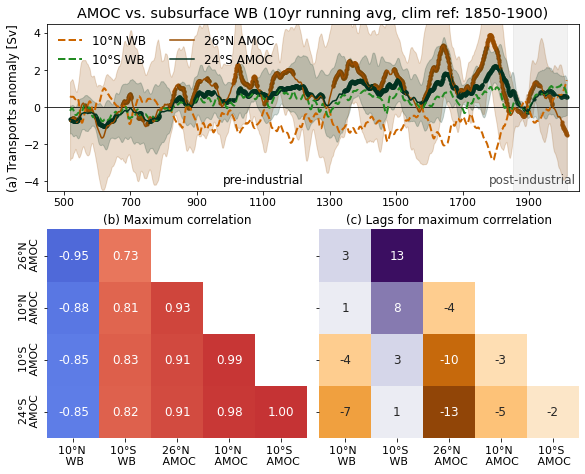

In [85]:
colorAMOCs = '#013220'
colorWBs = '#228B22'

colorAMOCn = '#994D00'
colorWBn = '#CC6600'

plt.rcParams.update({"font.size": 12,"xtick.labelsize": 11,"ytick.labelsize": 11,})
fig = plt.figure(figsize=(8, 6.5), constrained_layout=True)
#fig.set_constrained_layout_pads(w_pad=0.001, h_pad=0.03)
gs = fig.add_gridspec(nrows=2,ncols=2,height_ratios=[0.8, 1])  

### FIRST SUBPLOT -- AMOC time series
ax_AMOC = fig.add_subplot(gs[0, :])      # row 0, all columns
ax_AMOC.set_title('AMOC vs. subsurface WB (10yr running avg, clim ref: '+clim_ref+')')
ax_AMOC.set_ylabel('(a) Transports anomaly [Sv]')
ax_AMOC.axhline(y=0,c='k',lw=.8)

# VN WBC
ax_AMOC.plot(range(500,2015), anomVN_WBCtransp_mldTHCD_smooth.mean('record'),c=colorWBn,ls='--',lw='2',label='10\N{DEGREE SIGN}N WB')
# VS WBC
ax_AMOC.plot(range(500,2015), anomVS_WBCtransp_mldTHCD_smooth.mean('record'),c=colorWBs,ls='--',lw='2',label='10\N{DEGREE SIGN}S WB')
# AMOC 26N
x,y = stippling_signal_agreement(AMOC26anom_smooth2.vo,80)
ax_AMOC.fill_between(range(500,2015), AMOC26anom_smooth_conf.lb, AMOC26anom_smooth_conf.ub, color=colorAMOCn, alpha=.2)
ax_AMOC.plot(range(500,2015), AMOC26anom_smooth.mean('record').vo ,c=colorAMOCn,ls='-',lw='1.5', label='26\N{DEGREE SIGN}N AMOC')
ax_AMOC.scatter(x[1:],y[1:], color=colorAMOCn, marker='o', s=10, edgecolors=colorAMOCn) # stippling where the anomaly agrees on signal
# AMOC 24S
x,y = stippling_signal_agreement(AMOC24Sanom_smooth2.vo,80)
ax_AMOC.fill_between(range(500,2015), AMOC24Sanom_smooth_conf.lb, AMOC24Sanom_smooth_conf.ub, color=colorAMOCs, alpha=.2)
ax_AMOC.plot(range(500,2015), AMOC24Sanom_smooth.mean('record').vo ,c=colorAMOCs,ls='-',lw='1.5', label='24\N{DEGREE SIGN}S AMOC')
ax_AMOC.scatter(x[1:],y[1:], color=colorAMOCs, marker='o', s=10, edgecolors=colorAMOCs) # stippling where the anomaly agrees on signal

ax_AMOC.set_ylim(-4.5,4.5)
ax_AMOC.set_xlim(450,2050)
ax_AMOC.set_xticks(np.arange(500,2014,200))
ax_AMOC.legend(frameon=False, loc='upper left', ncol=2)
ax_AMOC.text(1100,-4.1,'pre-industrial',color='k',ha='center')
ax_AMOC.axvspan(1852, 2015, alpha=0.1, color='gray')
ax_AMOC.text(1910,-4.1,'post-industrial',color='#4D4D4D',ha='center')


### SECOND SUBPLOT -- CORRELATION
ax_corr = fig.add_subplot(gs[1, 0])    
corr = sns.heatmap(corr_heatmap,annot=True,fmt=".2f",cmap="coolwarm",mask=mask,
    vmin=-1.1,vmax=1.1,cbar=False,ax=ax_corr)
ax_corr.set_title("(b) Maximum correlation", fontsize=12)
ax_corr.set_xlabel("")
ax_corr.set_ylabel("")

### THIRD SUBPLOT -- LAGS
ax_lag = fig.add_subplot(gs[1, 1])      
lags = sns.heatmap(lag_heatmap,annot=True,fmt=".0f",cmap=cmaps.MPL_PuOr,mask=mask,
    vmin=-14,vmax=14,cbar=False,ax=ax_lag)
ax_lag.set_title("(c) Lags for maximum corrrelation", fontsize=12)
ax_lag.set_xlabel("")
ax_lag.set_ylabel("")
_ = plt.setp(ax_lag.get_yticklabels(), visible=False)

fig.savefig(PathFigures+'/figure_time_series_corr_AMOC_WB.png', format='png', bbox_inches='tight', dpi=300,  facecolor='white')
